MNIST IMAGE CLASSIFICATION USING RNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN ,Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [10]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [11]:
x_train = x_train / 255.0 # To normalize the pixel values, we divide by 255 (the maximum pixel value for grayscale images).
x_test = x_test / 255.0
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [14]:

num_classes = 10 # Number of classes in the MNIST dataset (digits 0-9)
y_train = to_categorical(y_train, num_classes) #1 hotencoding the labels
y_test = to_categorical(y_test, num_classes)

In [17]:
model = Sequential()
model.add(SimpleRNN(units=128,input_shape=(x_train.shape[1], x_train.shape[2])))
#model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=Adam(),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386 (83.54 KB)

 Trainable params: 21,386 (83.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8851 - loss: 0.3823 - val_accuracy: 0.9408 - val_loss: 0.2007
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9451 - loss: 0.1863 - val_accuracy: 0.9569 - val_loss: 0.1537
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9562 - loss: 0.1496 - val_accuracy: 0.9576 - val_loss: 0.1538
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9635 - loss: 0.1288 - val_accuracy: 0.9524 - val_loss: 0.1613
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9659 - loss: 0.1199 - val_accuracy: 0.9526 - val_loss: 0.1535


In [21]:
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f'Test Accuracy:{test_acc}')

313/313 - 1s - 4ms/step - accuracy: 0.9526 - loss: 0.1535
Test Accuracy:0.9526000022888184


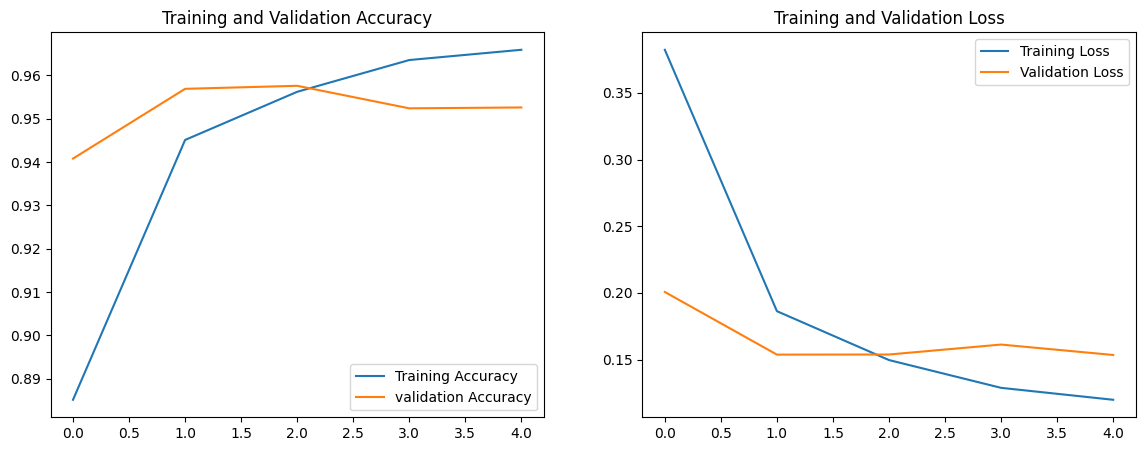

In [22]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./RNNM_NIST.png')
plt.show()
